In [27]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from random_forest import RandomForestClassifier
import matplotlib.pyplot as plt

In [28]:
wine_data = load_wine(as_frame=True)
df = wine_data.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [29]:
print(f"Total Observations (rows): {df.shape[0]}")
print(f"Total Features (columns): {df.shape[1]}")

Total Observations (rows): 178
Total Features (columns): 14


In [30]:
#Global informations about the dataset (Columns, shape, types, missing values...) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [31]:
#Check for Duplicate Values
duplicate_count = len(df[df.duplicated()])

if (duplicate_count>0):
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected in the data.")

No duplicate values detected in the data.


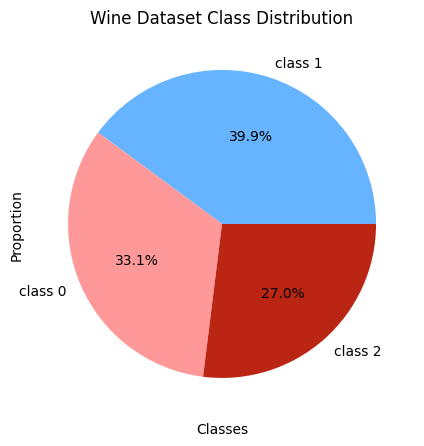

In [32]:
counts = df["target"].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(
    x=counts.values,
    labels=["class " + str(target) for target in counts.keys()],
    autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999', '#bb2514']
)

plt.title("Wine Dataset Class Distribution")

plt.xlabel("Classes")
plt.ylabel("Proportion")

plt.show()

In [33]:
X = df.drop("target", axis=1).values
y = df["target"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
model = RandomForestClassifier(n_estimators=10)
model.fit(X_train, y_train)

y_predicted = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=y_predicted)}")

Accuracy: 1.0
